## Pergunta Central

Quais fatores explicam a queda da desigualdade de renda no Brasil entre 2001 e 2014?

---

## Período de Análise

O estudo foca no intervalo de **2001 a 2014**, período marcado por:

- Crescimento econômico consistente
- Expansão de políticas sociais
- Boom das commodities
- Redução significativa do índice de desigualdade

---

## Variável Principal

A variável central do estudo é o:

### **Índice de Gini**

- Mede a desigualdade de renda
- Varia de **0 (igualdade perfeita)** a **100 (máxima desigualdade)**
- Será a variável **dependente (Y)** nas análises

---

## Objetivo Analítico

Investigar como diferentes fatores econômicos e estruturais contribuíram para a variação do Gini, incluindo:

- Crescimento econômico
- Gasto social
- Setor externo
- Estabilidade macroeconômica

---

## Hipótese Inicial

A queda da desigualdade no período não é explicada por um único fator, mas sim por um **alinhamento simultâneo de forças macroeconômicas e políticas públicas**.

# Tratamento de Dados

In [1]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Carregar os dados
df = pd.read_csv("data/df_final.csv")

# Visual inicial
print(df.head())
print(df.info())

# Remover valores ausentes
df = df.dropna()

# Garantir ordenação temporal
df = df.sort_values("ano")

# Resetar índice
df = df.reset_index(drop=True)

# Criar logs (caso queira garantir novamente)
df["log_pib"] = np.log(df["pib_ipea"])
df["log_social"] = np.log(df["gasto_social"])

# Conferência final
print("\nDataset após tratamento:")
print(df.head())
print("\nDimensão:", df.shape)

    ano  gini  pib_per_capita  inflacao       pib_ipea  gasto_social  \
0  2001  58.4     6823.033185  0.618333  109646.291667  5.665788e+08   
1  2002  58.1     6944.622576  0.991667  124065.591667  6.746159e+08   
2  2003  57.6     6941.439659  0.745833  143162.533333  7.500185e+08   
3  2004  56.5     7258.781017  0.612500  163145.925000  9.334566e+08   
4  2005  56.3     7409.568280  0.462500  180882.050000  1.053933e+09   

   export_pct_gdp   log_pib  log_social  
0       12.371711  8.828206   20.155127  
1       14.230590  8.845867   20.329654  
2       15.180784  8.845409   20.435608  
3       16.545762  8.890105   20.654405  
4       15.243829  8.910662   20.775794  
<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ano             13 non-null     int64  
 1   gini            13 non-null     float64
 2   pib_per_capita  13 non-null     float64

# Visualização do Índice de Gini

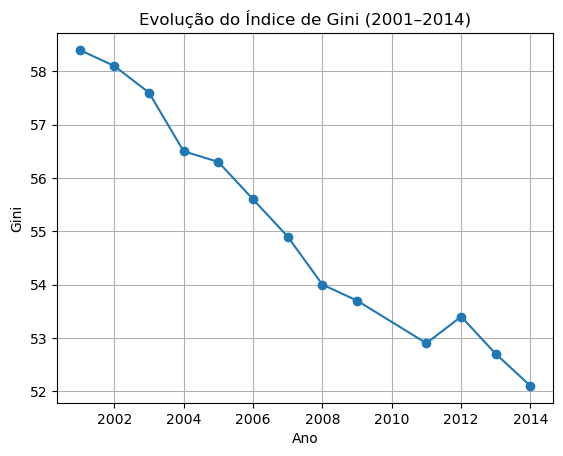

In [2]:
import matplotlib.pyplot as plt

# Garantir ordenação
df = df.sort_values("ano")

# Plot
plt.figure()
plt.plot(df["ano"], df["gini"], marker="o")

# Labels
plt.title("Evolução do Índice de Gini (2001–2014)")
plt.xlabel("Ano")
plt.ylabel("Gini")

# Grid
plt.grid()

# Exibir
plt.show()

# Visualização das Variáveis Explicativas

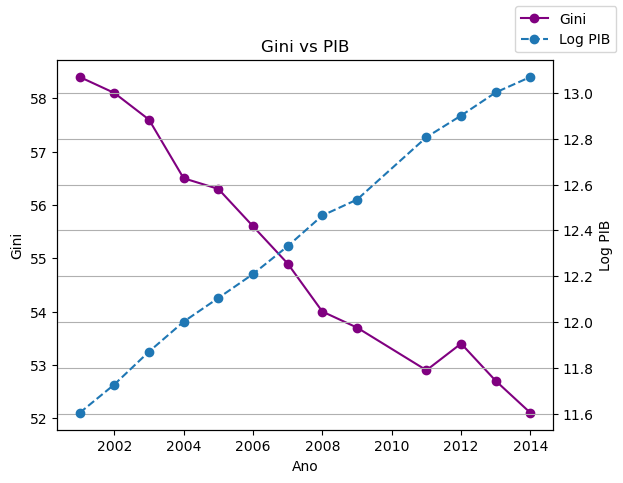

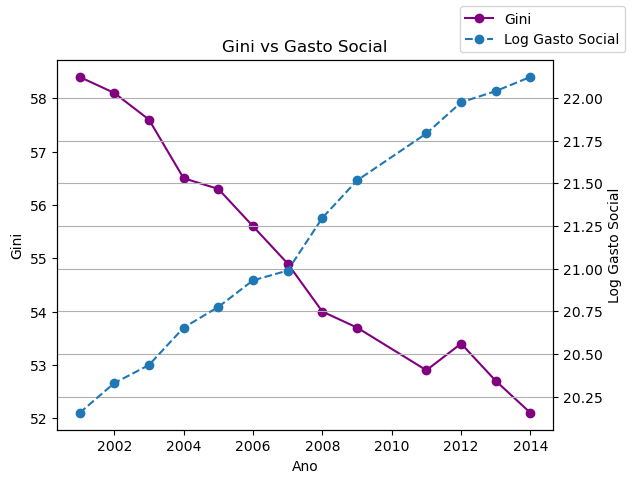

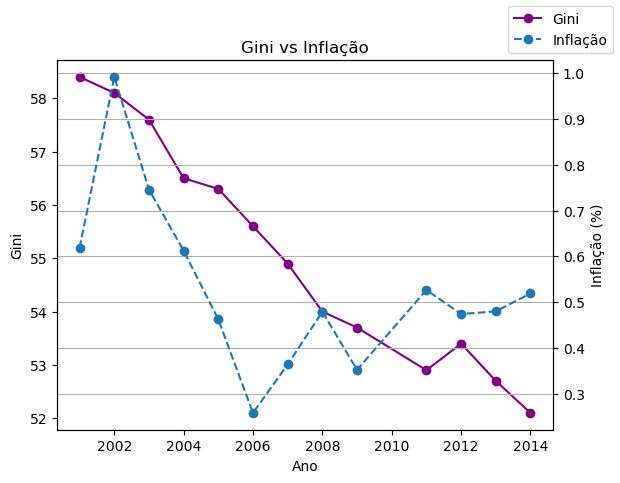

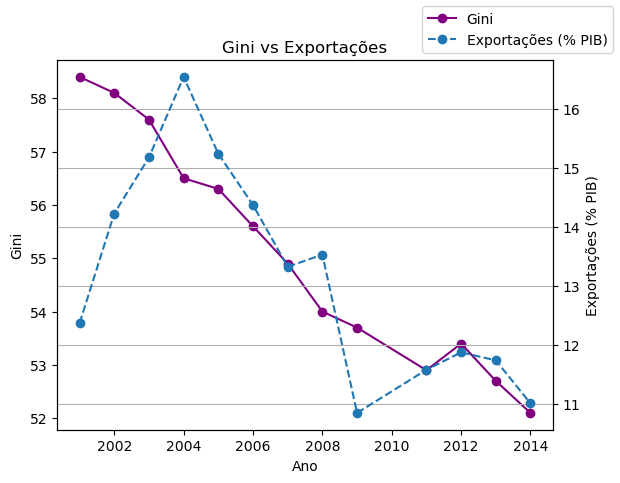

In [3]:
df = df.sort_values("ano")

# -------------------------
# Gini vs PIB (eixo duplo)
# -------------------------
fig, ax1 = plt.subplots()

ax1.plot(df["ano"], df["gini"], marker="o", label="Gini", color="purple")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Gini")

ax2 = ax1.twinx()
ax2.plot(df["ano"], df["log_pib"], marker="o", linestyle="--", label="Log PIB")
ax2.set_ylabel("Log PIB")

plt.title("Gini vs PIB")
fig.legend(loc="upper right")
plt.grid()
plt.show()


# -------------------------
# Gini vs Gasto Social
# -------------------------
fig, ax1 = plt.subplots()

ax1.plot(df["ano"], df["gini"], marker="o", label="Gini", color="purple")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Gini")

ax2 = ax1.twinx()
ax2.plot(df["ano"], df["log_social"], marker="o", linestyle="--", label="Log Gasto Social")
ax2.set_ylabel("Log Gasto Social")

plt.title("Gini vs Gasto Social")
fig.legend(loc="upper right")
plt.grid()
plt.show()

# -------------------------
# Gini vs Inflação
# -------------------------
fig, ax1 = plt.subplots()

ax1.plot(df["ano"], df["gini"], marker="o", label="Gini", color="purple")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Gini")

ax2 = ax1.twinx()
ax2.plot(df["ano"], df["inflacao"], marker="o", linestyle="--", label="Inflação")
ax2.set_ylabel("Inflação (%)")

plt.title("Gini vs Inflação")
fig.legend(loc="upper right")
plt.grid()
plt.show()


# -------------------------
# Gini vs Exportações
# -------------------------
fig, ax1 = plt.subplots()

ax1.plot(df["ano"], df["gini"], marker="o", label="Gini", color="purple")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Gini")

ax2 = ax1.twinx()
ax2.plot(df["ano"], df["export_pct_gdp"], marker="o", linestyle="--", label="Exportações (% PIB)")
ax2.set_ylabel("Exportações (% PIB)")

plt.title("Gini vs Exportações")
fig.legend(loc="upper right")
plt.grid()
plt.show()

# Análise de Correlação

In [4]:
# Selecionar variáveis relevantes
corr_vars = df[[
    "gini",
    "log_pib",
    "log_social",
    "export_pct_gdp",
    "inflacao"
]]

# Calcular matriz de correlação
corr_matrix = corr_vars.corr()

# Exibir matriz
print("Matriz de Correlação:\n")
print(corr_matrix)

# Correlação específica com Gini
print("\nCorrelação com Gini:\n")
print(corr_matrix["gini"].sort_values())

Matriz de Correlação:

                    gini   log_pib  log_social  export_pct_gdp  inflacao
gini            1.000000 -0.983356   -0.979426        0.680658  0.560731
log_pib        -0.983356  1.000000    0.996193       -0.676265 -0.490208
log_social     -0.979426  0.996193    1.000000       -0.706584 -0.472656
export_pct_gdp  0.680658 -0.676265   -0.706584        1.000000  0.296161
inflacao        0.560731 -0.490208   -0.472656        0.296161  1.000000

Correlação com Gini:

log_pib          -0.983356
log_social       -0.979426
inflacao          0.560731
export_pct_gdp    0.680658
gini              1.000000
Name: gini, dtype: float64


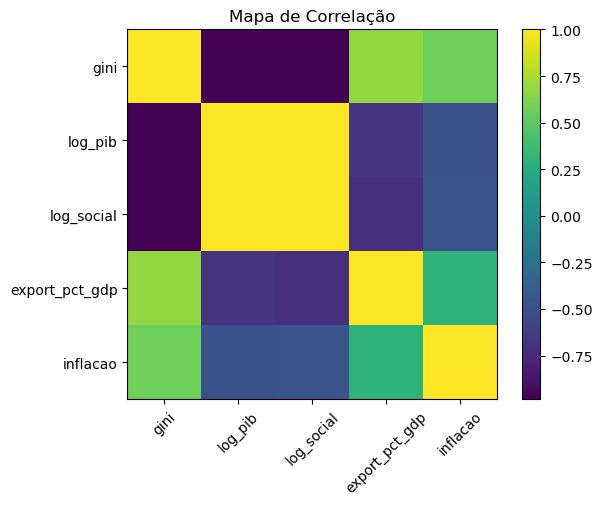

In [5]:
plt.figure()
plt.imshow(corr_matrix)
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Mapa de Correlação")
plt.show()

# Regressão OLS (Modelo Base)

In [6]:
import statsmodels.api as sm

# Definir variável dependente
y = df["gini"]

# Definir variáveis independentes
X = df[[
    "log_pib",
    "log_social",
    "export_pct_gdp",
    "inflacao"
]]

# Adicionar constante (β0)
X = sm.add_constant(X)

# Rodar regressão OLS
model = sm.OLS(y, X).fit()

# Resultado
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   gini   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                     80.79
Date:                Sat, 02 May 2026   Prob (F-statistic):           1.67e-06
Time:                        18:47:01   Log-Likelihood:                -3.6785
No. Observations:                  13   AIC:                             17.36
Df Residuals:                       8   BIC:                             20.18
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            104.0155     12.413      8.

# Regressão com Defasagem

In [7]:
# Criar variáveis defasadas (lag 1)
df["log_pib_lag1"] = df["log_pib"].shift(1)
df["log_social_lag1"] = df["log_social"].shift(1)

# Remover NaN gerado pela defasagem
df_lag = df.dropna()

# Variável dependente
y = df_lag["gini"]

# Variáveis independentes (com lag)
X = df_lag[[
    "log_pib_lag1",
    "log_social_lag1",
    "export_pct_gdp",
    "inflacao"
]]

# Adicionar constante
X = sm.add_constant(X)

# Rodar regressão
model_lag = sm.OLS(y, X).fit()

# Resultado
print(model_lag.summary())

                            OLS Regression Results                            
Dep. Variable:                   gini   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     37.51
Date:                Sat, 02 May 2026   Prob (F-statistic):           8.13e-05
Time:                        18:47:01   Log-Likelihood:                -6.1104
No. Observations:                  12   AIC:                             22.22
Df Residuals:                       7   BIC:                             24.65
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              86.7150     17.316     

# Fator Externo: Exportações e Commodities

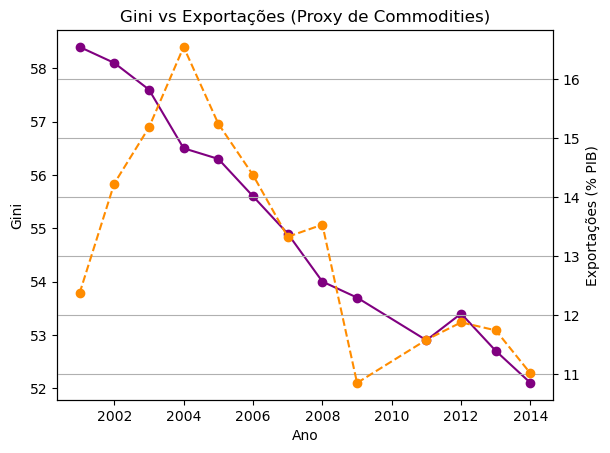

Correlação Gini vs Exportações: 0.6806580675022176


In [8]:
df = df.sort_values("ano")

# -------------------------
# Gráfico com eixo duplo
# -------------------------
fig, ax1 = plt.subplots()

ax1.plot(df["ano"], df["gini"], marker="o", label="Gini", color="purple")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Gini")

ax2 = ax1.twinx()
ax2.plot(df["ano"], df["export_pct_gdp"], marker="o", linestyle="--", color='darkorange')
ax2.set_ylabel("Exportações (% PIB)")

plt.title("Gini vs Exportações (Proxy de Commodities)")
plt.grid()
plt.show()

# -------------------------
# Correlação isolada
# -------------------------
corr_export = df["gini"].corr(df["export_pct_gdp"])

print("Correlação Gini vs Exportações:", corr_export)

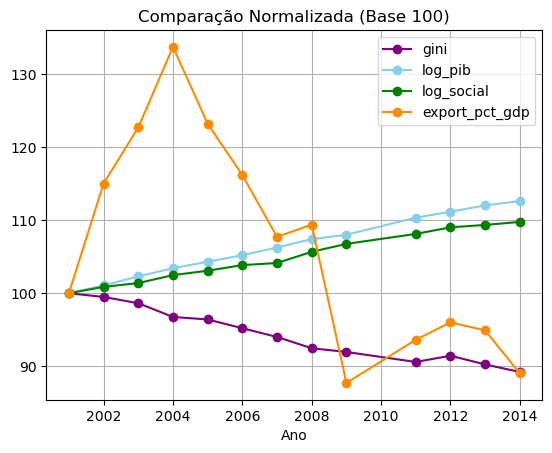

In [9]:

# Normalização base 100 para comparar tendências
df_norm = df.copy()

cols = ["gini", "log_pib", "log_social", "export_pct_gdp"]
colors = ["purple", "skyblue", "green", "darkorange"]

for col in cols:
    df_norm[col] = df_norm[col] / df_norm[col].iloc[0] * 100

import matplotlib.pyplot as plt

plt.figure()

for col in cols:
    plt.plot(df_norm["ano"], df_norm[col], marker="o", label=col, color=colors[cols.index(col)])

plt.title("Comparação Normalizada (Base 100)")
plt.xlabel("Ano")
plt.legend()
plt.grid()

plt.show()

# Decomposição Intuitiva da Queda do Gini

Esta etapa interpreta os resultados empíricos para entender quais fatores estão associados à redução da desigualdade no período analisado.

---

## Evidências Empíricas

### Crescimento Econômico

- Correlação com Gini: -0.98 (muito forte)
- Relação visual consistente ao longo do tempo

Interpretação:

O crescimento econômico está fortemente associado à redução da desigualdade. À medida que o PIB cresce, o Gini tende a cair.

---

### Gasto Social

- Correlação com Gini: -0.97 (muito forte)
- Crescimento contínuo no período

Interpretação:

O aumento do gasto social também apresenta forte associação com a queda do Gini, sugerindo efeito redistributivo relevante.

---

### Exportações (Setor Externo)

- Correlação com Gini: +0.68 (moderada e positiva)
- Forte crescimento até 2004–2005, seguido de queda

Interpretação:

O comportamento das exportações não acompanha a queda do Gini de forma consistente. Após o pico, as exportações caem enquanto o Gini continua reduzindo.

Isso sugere que o setor externo não é o principal fator explicativo isolado.

---

### Inflação

- Correlação com Gini: +0.56 (moderada)
- Variação relativamente instável

Interpretação:

A inflação apresenta associação positiva com o Gini, mas sem padrão claro ao longo do tempo. Seu papel parece secundário.

---

## Problema de Multicolinearidade

As variáveis de crescimento e gasto social apresentam correlação extremamente alta entre si:

- Corr(log_pib, log_social) ≈ 0.996

Isso implica:

- Dificuldade em separar efeitos individuais
- Coeficientes da regressão pouco confiáveis isoladamente
- Possível instabilidade estatística

---

## Síntese Analítica

Os resultados indicam que:

- Crescimento econômico e gasto social estão fortemente associados à queda da desigualdade
- Essas variáveis evoluem de forma conjunta no período
- O modelo apresenta alto poder explicativo (R² ≈ 0.97), apesar da limitação estrutural

---

## Interpretação Central

A queda do Gini não pode ser atribuída a um único fator.

Ela está associada a um movimento conjunto de:

- Expansão econômica
- Aumento do gasto social
- Contexto externo parcialmente favorável

---

## Conclusão Parcial

A evidência sugere que a redução da desigualdade no período resulta de um alinhamento de fatores macroeconômicos, mas com forte interdependência entre eles, o que limita a identificação de efeitos causais isolados.

====================


# Cenários Contrafactuais Intuitivos

Nesta etapa, construímos cenários hipotéticos para interpretar a importância relativa dos fatores associados à queda do Gini.

---

## Objetivo

Avaliar, de forma intuitiva, como a desigualdade poderia se comportar na ausência de alguns dos principais vetores observados no período.

---

## Cenário 1: Sem crescimento econômico

Se o PIB não tivesse crescido no período, é plausível esperar que:

- a renda média tivesse avançado menos;
- o mercado de trabalho tivesse absorvido menos trabalhadores;
- a redução da desigualdade fosse menor.

Interpretação:

O crescimento econômico parece ter funcionado como uma base importante para a queda do Gini.

---

## Cenário 2: Sem expansão do gasto social

Se o gasto social não tivesse aumentado, seria razoável supor que:

- a redistribuição de renda teria sido mais fraca;
- a renda das camadas mais pobres teria crescido menos;
- a queda do Gini teria perdido intensidade.

Interpretação:

A política social parece ter atuado como mecanismo direto de redução da desigualdade.

---

## Cenário 3: Sem melhora do setor externo

Se o ambiente externo tivesse sido menos favorável, com exportações mais fracas, o país possivelmente teria enfrentado:

- menor geração de receita;
- menor impulso ao crescimento;
- menor espaço fiscal para políticas públicas.

Interpretação:

O setor externo não explica sozinho a queda do Gini, mas pode ter contribuído para criar condições macroeconômicas favoráveis.

---

## Leitura Geral

Os cenários sugerem que a queda da desigualdade dependeu da combinação de fatores, e não de uma única variável isolada.

Em termos analíticos:

- sem crescimento, a queda do Gini provavelmente seria menor;
- sem gasto social, o efeito redistributivo seria mais fraco;
- sem setor externo favorável, o contexto macroeconômico seria menos propício.

---

## Limitação

Esses cenários não representam simulações causais formais.

Eles servem apenas como ferramenta interpretativa para organizar a evidência empírica e reforçar a leitura econômica do período.

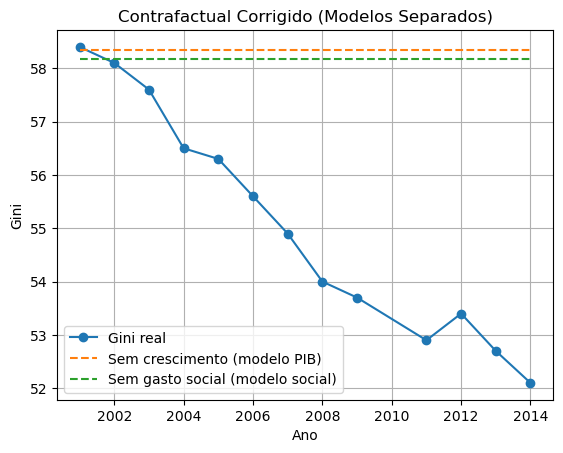

In [10]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# -------------------------
# MODELO 1: Gini ~ PIB
# -------------------------
X_pib = sm.add_constant(df["log_pib"])
model_pib = sm.OLS(df["gini"], X_pib).fit()

# Contrafactual: PIB constante
df_cf_pib = df.copy()
df_cf_pib["log_pib"] = df_cf_pib["log_pib"].iloc[0]

X_cf_pib = sm.add_constant(df_cf_pib["log_pib"], has_constant='add')
df_cf_pib["gini_cf_sem_pib"] = model_pib.predict(X_cf_pib)


# -------------------------
# MODELO 2: Gini ~ Gasto Social
# -------------------------
X_soc = sm.add_constant(df["log_social"])
model_soc = sm.OLS(df["gini"], X_soc).fit()

# Contrafactual: gasto constante
df_cf_soc = df.copy()
df_cf_soc["log_social"] = df_cf_soc["log_social"].iloc[0]

X_cf_soc = sm.add_constant(df_cf_soc["log_social"], has_constant='add')
df_cf_soc["gini_cf_sem_social"] = model_soc.predict(X_cf_soc)


# -------------------------
# PLOT FINAL
# -------------------------
plt.figure()

plt.plot(df["ano"], df["gini"], marker="o", label="Gini real")
plt.plot(df["ano"], df_cf_pib["gini_cf_sem_pib"], linestyle="--", label="Sem crescimento (modelo PIB)")
plt.plot(df["ano"], df_cf_soc["gini_cf_sem_social"], linestyle="--", label="Sem gasto social (modelo social)")

plt.title("Contrafactual Corrigido (Modelos Separados)")
plt.xlabel("Ano")
plt.ylabel("Gini")

plt.legend()
plt.grid()

plt.show()

# Limitações do Modelo

Esta seção apresenta as principais limitações da análise empírica, essenciais para a correta interpretação dos resultados.

---

## Tamanho da Amostra

- O estudo utiliza aproximadamente 12–13 observações anuais
- Isso reduz o poder estatístico dos testes
- Pequenas variações podem gerar mudanças relevantes nos coeficientes

Implicação:

Os resultados devem ser interpretados como indicativos, não conclusivos.

---

## Multicolinearidade

As variáveis de crescimento econômico e gasto social apresentam correlação extremamente elevada:

- Corr(log_pib, log_social) ≈ 0.996

Implicações:

- Dificuldade em separar efeitos individuais
- Coeficientes instáveis na regressão múltipla
- Possível perda de significância estatística

Consequência:

O modelo explica bem o Gini em conjunto, mas não identifica com precisão o impacto isolado de cada variável.

---

## Correlação não implica causalidade

- A análise é baseada em correlações e regressões OLS
- Não há identificação causal formal

Possíveis problemas:

- Variáveis omitidas (ex: mercado de trabalho, educação)
- Endogeneidade (ex: crescimento pode ser influenciado pela própria desigualdade)

---

## Simplificação das variáveis

Algumas variáveis são proxies:

- Exportações (% PIB) como proxy de commodities
- PIB e gasto social como agregados amplos

Implicação:

Os mecanismos reais podem ser mais complexos do que os capturados no modelo.

---

## Contrafactuais aproximados

Os cenários contrafactuais construídos:

- Baseiam-se em modelos reduzidos
- Não representam simulações estruturais
- Não capturam feedbacks entre variáveis

Implicação:

Devem ser interpretados como exercícios ilustrativos, não como previsões causais.

---

## Especificação do modelo

- O modelo assume relação linear entre variáveis
- Não considera dinâmicas mais complexas
- Não inclui todas as dimensões relevantes da desigualdade

---

## Conclusão das Limitações

A análise oferece evidências consistentes de associação entre variáveis macroeconômicas e a desigualdade, mas não permite inferência causal robusta.

Os resultados devem ser interpretados como parte de uma análise exploratória, útil para gerar hipóteses e orientar investigações futuras.